<a href="https://colab.research.google.com/github/Abeer-Alsafran-ku/G-DINO/blob/main/grounding_dino_tiny.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -U transformers

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Dataset

In [17]:
# Use a pipeline as a high-level helper
from transformers import pipeline
import requests
import json
from pathlib import Path
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
from PIL import Image,ImageDraw
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection


In [12]:
import os

train_path = '/content/drive/MyDrive/Kdrone4/train'
test_path = '/content/drive/MyDrive/Kdrone4/test'
val_path = '/content/drive/MyDrive/Kdrone4/valid'


train = os.listdir('/content/drive/MyDrive/Kdrone4/train')
test = os.listdir('/content/drive/MyDrive/Kdrone4/test')
val = os.listdir('/content/drive/MyDrive/Kdrone4/valid')

GROUND_TRUTH_JSON_PATH = Path(test_path) / "_annotations.coco.json"

print(f"Total = {len(train) + len(test) + len(val)}")
print(f"Train = {len(train)}")
print(f"Test = {len(test)}")
print(f"Val = {len(val)}")

print("Specifications = Auto-Orient: Applied Resize: Stretch to 1024x1024 Tile: 2 rows x 2 columns Edit 4 Augmentation 90° Rotate: Clockwise, Counter-Clockwise, Upside Down Saturation: Between -25% and +25% Brightness: Between -20% and +20% Exposure: Between -4% and +4% Blur: Up to 0.8px Noise: Up to 0.1% of pixels Mosaic: Applied")

Total = 5019
Train = 4381
Test = 421
Val = 217
Specifications = Auto-Orient: Applied Resize: Stretch to 1024x1024 Tile: 2 rows x 2 columns Edit 4 Augmentation 90° Rotate: Clockwise, Counter-Clockwise, Upside Down Saturation: Between -25% and +25% Brightness: Between -20% and +20% Exposure: Between -4% and +4% Blur: Up to 0.8px Noise: Up to 0.1% of pixels Mosaic: Applied


## Local Inference on GPU
Model page: https://huggingface.co/IDEA-Research/grounding-dino-tiny

⚠️ If the generated code snippets do not work, please open an issue on either the [model repo](https://huggingface.co/IDEA-Research/grounding-dino-tiny)
			and/or on [huggingface.js](https://github.com/huggingface/huggingface.js/blob/main/packages/tasks/src/model-libraries-snippets.ts) 🙏

In [ ]:
pipe = pipeline("zero-shot-object-detection", model="IDEA-Research/grounding-dino-tiny")

# Load model directly
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

processor = AutoProcessor.from_pretrained("IDEA-Research/grounding-dino-tiny")
model = AutoModelForZeroShotObjectDetection.from_pretrained("IDEA-Research/grounding-dino-tiny")

Loading weights:   0%|          | 0/978 [00:00<?, ?it/s]

In [ ]:
image_url = "/content/drive/MyDrive/Kdrone4/test/20221016_436_Flight_02_01317_JPG.rf.5caa5888b2636aba47627cddadf0eacb.jpg"
image = Image.open(image_url)
# Check for cats and remote controls
# VERY important: text queries need to be lowercased + end with a dot
text = "car . bus . truck . pickup-truck . van"
device = "cuda" if torch.cuda.is_available() else "cpu"

# Move the model to the specified device
model.to(device)

inputs = processor(images=image, text=text, return_tensors="pt").to(device)
with torch.no_grad():
    outputs = model(**inputs)

results = processor.post_process_grounded_object_detection(
    outputs,
    inputs.input_ids,
    target_sizes=[image.size[::-1]]
)

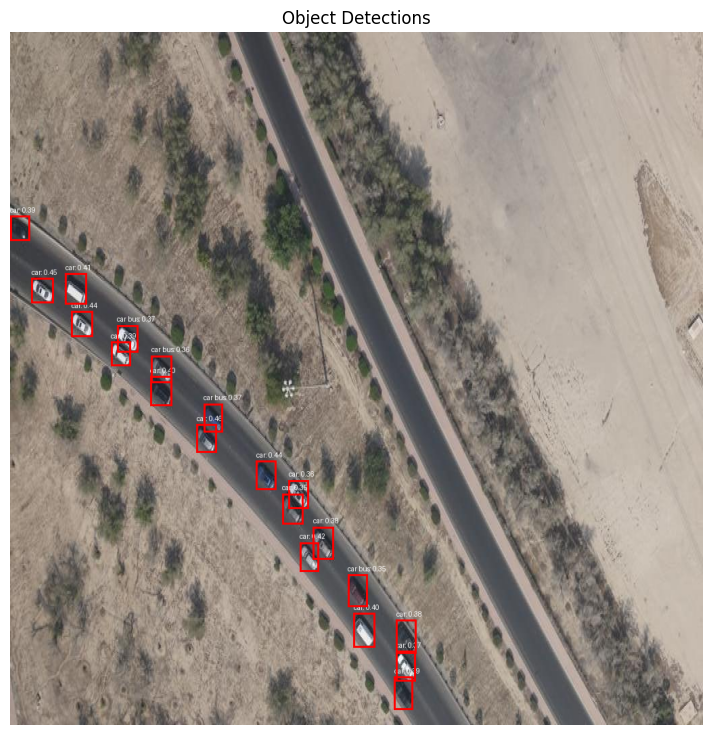

In [ ]:
import matplotlib.pyplot as plt
from PIL import ImageDraw

# Make a copy of the image to draw on
draw_image = image.copy()
draw = ImageDraw.Draw(draw_image)

# Get the results from the first (and only) item in the results list
prediction = results[0]

# Define colors for bounding boxes and text
box_color = "red"
text_color = "white"

# Iterate through the predicted boxes, labels, and scores
for box, label, score in zip(prediction['boxes'], prediction['text_labels'], prediction['scores']):
    x_min, y_min, x_max, y_max = box.tolist()

    # Draw bounding box
    draw.rectangle((x_min, y_min, x_max, y_max), outline=box_color, width=3)

    # Draw label and score
    label_text = f"{label}: {score.item():.2f}"
    text_position = (x_min, y_min - 15) # Position text slightly above the box
    draw.text(text_position, label_text, fill=text_color, font=None) # Default font will be used

# Display the image with bounding boxes
plt.figure(figsize=(12, 9))
plt.imshow(draw_image)
plt.axis('off')
plt.title('Object Detections')
plt.show()

In [ ]:
import pandas as pd

# Extract bounding box data
boxes_data = []
prediction = results[0]

for i, (box, label, score) in enumerate(zip(prediction['boxes'], prediction['text_labels'], prediction['scores'])):
    x_min, y_min, x_max, y_max = box.tolist()
    boxes_data.append({
        'object_id': i,
        'label': label,
        'score': score.item(),
        'x_min': x_min,
        'y_min': y_min,
        'x_max': x_max,
        'y_max': y_max
    })

# Create a DataFrame
df_detections = pd.DataFrame(boxes_data)

# Save to CSV
output_csv_path = '/content/detected_objects.csv'
df_detections.to_csv(output_csv_path, index=False)

print(f"Detected objects saved to {output_csv_path}")
display(df_detections.head())

Detected objects saved to /content/detected_objects.csv


,object_id,label,score,x_min,y_min,x_max,y_max
0,0,car,0.459846,275.535278,579.591187,305.012573,621.783447
1,1,car,0.422733,428.398041,754.223633,456.495392,797.455322
2,2,car,0.402982,507.866241,858.670044,539.685303,909.467041
3,3,car,0.435104,363.900055,633.669861,393.357391,676.888000
4,4,car,0.441783,90.811218,412.576965,122.977676,450.423157


# Predict Test set

SET UP

In [11]:
# -*- coding: utf-8 -*-
"""grounding_dino_tiny.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/github/Abeer-Alsafran-ku/G-DINO/blob/main/grounding_dino_tiny.ipynb
"""

!pip install -U transformers

from google.colab import drive
drive.mount('/content/drive')

"""## Dataset"""

import os

train_path = '/content/drive/MyDrive/Kdrone4/train'
test_path = '/content/drive/MyDrive/Kdrone4/test'
val_path = '/content/drive/MyDrive/Kdrone4/valid'


train = os.listdir('/content/drive/MyDrive/Kdrone4/train')
test = os.listdir('/content/drive/MyDrive/Kdrone4/test')
val = os.listdir('/content/drive/MyDrive/Kdrone4/valid')

print(f"Total = {len(train) + len(test) + len(val)}")
print(f"Train = {len(train)}")
print(f"Test = {len(test)}")
print(f"Val = {len(val)}")

print("Specifications = Auto-Orient: Applied Resize: Stretch to 1024x1024 Tile: 2 rows x 2 columns Edit 4 Augmentation 90° Rotate: Clockwise, Counter-Clockwise, Upside Down Saturation: Between -25% and +25% Brightness: Between -20% and +20% Exposure: Between -4% and +4% Blur: Up to 0.8px Noise: Up to 0.1% of pixels Mosaic: Applied")

"""## Local Inference on GPU
Model page: https://huggingface.co/IDEA-Research/grounding-dino-tiny

⚠️ If the generated code snippets do not work, please open an issue on either the [model repo](https://huggingface.co/IDEA-Research/grounding-dino-tiny)
			and/or on [huggingface.js](https://github.com/huggingface/huggingface.js/blob/main/packages/tasks/src/model-libraries-snippets.ts) 🙏
"""

import torch
from PIL import Image
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 145.9 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.12.0
    Uninstalling transformers-5.12.0:
      Successfully uninstalled transformers-5.12.0


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total = 5019
Train = 4381
Test = 421
Val = 217
Specifications = Auto-Orient: Applied Resize: Stretch to 1024x1024 Tile: 2 rows x 2 columns Edit 4 Augmentation 90° Rotate: Clockwise, Counter-Clockwise, Upside Down Saturation: Between -25% and +25% Brightness: Between -20% and +20% Exposure: Between -4% and +4% Blur: Up to 0.8px Noise: Up to 0.1% of pixels Mosaic: Applied


MODEL LOADING AND GLOBALS

In [ ]:
processor = AutoProcessor.from_pretrained("IDEA-Research/grounding-dino-tiny")
model = AutoModelForZeroShotObjectDetection.from_pretrained("IDEA-Research/grounding-dino-tiny")

device = "cuda" if torch.cuda.is_available() else "cpu"

# Move the model to the specified device
model.to(device)
model.eval()

import matplotlib.pyplot as plt
from PIL import ImageDraw
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm

# VERY important: text queries need to be lowercased + end with a dot
text = "car . bus . truck . pickup-truck . van"

# Tune these if you want more/less strict predictions.
BOX_THRESHOLD = 0.30
TEXT_THRESHOLD = 0.25

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.64k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/689M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/978 [00:00<?, ?it/s]

FUNCTIONS

In [ ]:
def find_images(root_dir):
    root = Path(root_dir)
    return sorted(
        path for path in root.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )


def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, text=text, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    try:
        results = processor.post_process_grounded_object_detection(
            outputs,
            inputs.input_ids,
            box_threshold=BOX_THRESHOLD,
            text_threshold=TEXT_THRESHOLD,
            target_sizes=[image.size[::-1]]
        )
    except TypeError as error:
        if "box_threshold" not in str(error):
            raise
        results = processor.post_process_grounded_object_detection(
            outputs,
            inputs.input_ids,
            threshold=BOX_THRESHOLD,
            text_threshold=TEXT_THRESHOLD,
            target_sizes=[image.size[::-1]]
        )

    return image, results[0]


def draw_prediction(image, prediction):
    draw_image = image.copy()
    draw = ImageDraw.Draw(draw_image)

    for box, label, score in zip(
        prediction["boxes"],
        prediction["text_labels"],
        prediction["scores"]
    ):
        x_min, y_min, x_max, y_max = box.tolist()
        draw.rectangle((x_min, y_min, x_max, y_max), outline="red", width=3)
        draw.text((x_min, max(0, y_min - 15)), f"{label}: {score.item():.2f}", fill="white")

    return draw_image



DRIVER

Found 420 test images


Predicting test images:   0%|          | 0/420 [00:00<?, ?it/s]

Detection rows saved to /content/drive/MyDrive/Kdrone4/predictions/grounding_dino_tiny/test_detections.csv
Detection JSON saved to /content/drive/MyDrive/Kdrone4/predictions/grounding_dino_tiny/test_detections.json
Image summary saved to /content/drive/MyDrive/Kdrone4/predictions/grounding_dino_tiny/test_image_summary.csv


,image_name,relative_image_path,image_path,object_id,label,score,x_min,y_min,x_max,y_max,image_width,image_height,text_prompt,box_threshold,text_threshold,model_name
0,20221016_436_Flight_02_01317_JPG.rf.5caa5888b2...,20221016_436_Flight_02_01317_JPG.rf.5caa5888b2...,/content/drive/MyDrive/Kdrone4/test/20221016_4...,0,car,0.459846,275.535278,579.591187,305.012573,621.783447,1024,1024,car . bus . truck . pickup-truck . van,0.3,0.25,IDEA-Research/grounding-dino-tiny
1,20221016_436_Flight_02_01317_JPG.rf.5caa5888b2...,20221016_436_Flight_02_01317_JPG.rf.5caa5888b2...,/content/drive/MyDrive/Kdrone4/test/20221016_4...,1,car,0.422733,428.398041,754.223633,456.495392,797.455322,1024,1024,car . bus . truck . pickup-truck . van,0.3,0.25,IDEA-Research/grounding-dino-tiny
2,20221016_436_Flight_02_01317_JPG.rf.5caa5888b2...,20221016_436_Flight_02_01317_JPG.rf.5caa5888b2...,/content/drive/MyDrive/Kdrone4/test/20221016_4...,2,car,0.402982,507.866241,858.670044,539.685303,909.467041,1024,1024,car . bus . truck . pickup-truck . van,0.3,0.25,IDEA-Research/grounding-dino-tiny
3,20221016_436_Flight_02_01317_JPG.rf.5caa5888b2...,20221016_436_Flight_02_01317_JPG.rf.5caa5888b2...,/content/drive/MyDrive/Kdrone4/test/20221016_4...,3,car,0.435104,363.900055,633.669861,393.357391,676.888000,1024,1024,car . bus . truck . pickup-truck . van,0.3,0.25,IDEA-Research/grounding-dino-tiny
4,20221016_436_Flight_02_01317_JPG.rf.5caa5888b2...,20221016_436_Flight_02_01317_JPG.rf.5caa5888b2...,/content/drive/MyDrive/Kdrone4/test/20221016_4...,4,car,0.441783,90.811218,412.576965,122.977676,450.423157,1024,1024,car . bus . truck . pickup-truck . van,0.3,0.25,IDEA-Research/grounding-dino-tiny


,image_name,relative_image_path,image_path,num_detections,top_label,top_score,image_width,image_height
0,20221016_436_Flight_02_01317_JPG.rf.5012e1b6c8...,20221016_436_Flight_02_01317_JPG.rf.5012e1b6c8...,/content/drive/MyDrive/Kdrone4/test/20221016_4...,1,,NaN,1024,1024
1,20221016_436_Flight_02_01317_JPG.rf.5caa5888b2...,20221016_436_Flight_02_01317_JPG.rf.5caa5888b2...,/content/drive/MyDrive/Kdrone4/test/20221016_4...,20,car,0.459846,1024,1024
2,20221016_436_Flight_02_01317_JPG.rf.76b73a95d2...,20221016_436_Flight_02_01317_JPG.rf.76b73a95d2...,/content/drive/MyDrive/Kdrone4/test/20221016_4...,1,,NaN,1024,1024
3,20221016_436_Flight_02_01317_JPG.rf.a027e575f2...,20221016_436_Flight_02_01317_JPG.rf.a027e575f2...,/content/drive/MyDrive/Kdrone4/test/20221016_4...,20,car,0.518264,1024,1024
4,20221016_436_Flight_02_01579_JPG.rf.5d9b1b4e64...,20221016_436_Flight_02_01579_JPG.rf.5d9b1b4e64...,/content/drive/MyDrive/Kdrone4/test/20221016_4...,5,car,0.366671,1024,1024


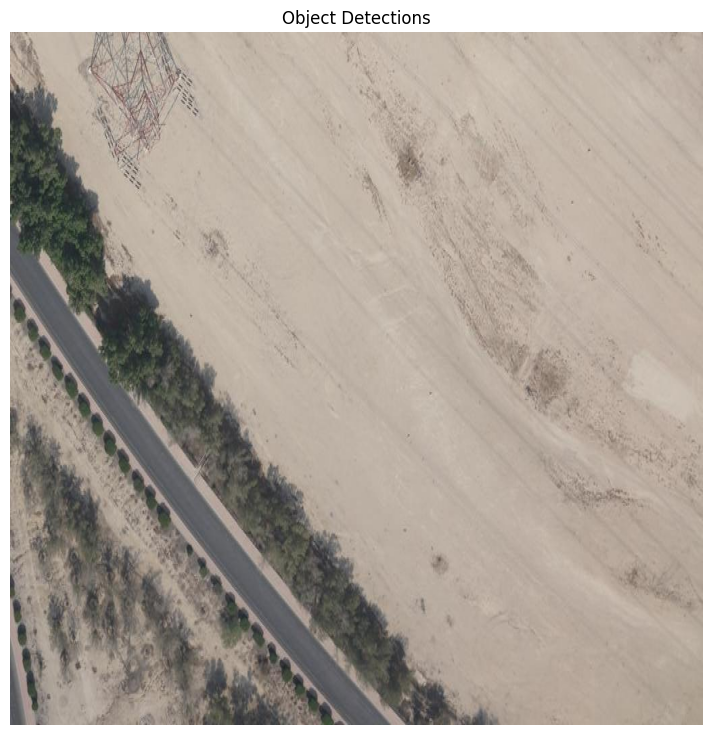

In [ ]:

test_images = find_images(test_path)
print(f"Found {len(test_images)} test images")

prediction_rows = []
summary_rows = []
detection_columns = [
    "image_name",
    "relative_image_path",
    "image_path",
    "object_id",
    "label",
    "score",
    "x_min",
    "y_min",
    "x_max",
    "y_max",
    "image_width",
    "image_height",
    "text_prompt",
    "box_threshold",
    "text_threshold",
    "model_name"
]
summary_columns = [
    "image_name",
    "relative_image_path",
    "image_path",
    "num_detections",
    "top_label",
    "top_score",
    "image_width",
    "image_height"
]

for image_path in tqdm(test_images, desc="Predicting test images"):
    image, prediction = predict_image(image_path)
    image_name = image_path.name
    relative_image_path = str(image_path.relative_to(test_path))
    image_width, image_height = image.size
    labels = prediction["text_labels"]
    scores = prediction["scores"]
    boxes = prediction["boxes"]

    for object_id, (box, label, score) in enumerate(zip(boxes, labels, scores)):
        x_min, y_min, x_max, y_max = box.tolist()
        prediction_rows.append({
            "image_name": image_name,
            "relative_image_path": relative_image_path,
            "image_path": str(image_path),
            "object_id": object_id,
            "label": label,
            "score": float(score.item()),
            "x_min": float(x_min),
            "y_min": float(y_min),
            "x_max": float(x_max),
            "y_max": float(y_max),
            "image_width": image_width,
            "image_height": image_height,
            "text_prompt": text,
            "box_threshold": BOX_THRESHOLD,
            "text_threshold": TEXT_THRESHOLD,
            "model_name": "IDEA-Research/grounding-dino-tiny"
        })

    top_label = labels[0] if len(labels) else None
    top_score = float(scores[0].item()) if len(scores) else None
    summary_rows.append({
        "image_name": image_name,
        "relative_image_path": relative_image_path,
        "image_path": str(image_path),
        "num_detections": len(labels),
        "top_label": top_label,
        "top_score": top_score,
        "image_width": image_width,
        "image_height": image_height
    })

df_detections = pd.DataFrame(prediction_rows, columns=detection_columns)
df_summary = pd.DataFrame(summary_rows, columns=summary_columns)

output_dir = Path("/content/drive/MyDrive/Kdrone4/predictions/grounding_dino_tiny")
output_dir.mkdir(parents=True, exist_ok=True)

detections_csv_path = output_dir / "test_detections.csv"
detections_json_path = output_dir / "test_detections.json"
summary_csv_path = output_dir / "test_image_summary.csv"

df_detections.to_csv(detections_csv_path, index=False)
df_detections.to_json(detections_json_path, orient="records", indent=2)
df_summary.to_csv(summary_csv_path, index=False)

print(f"Detection rows saved to {detections_csv_path}")
print(f"Detection JSON saved to {detections_json_path}")
print(f"Image summary saved to {summary_csv_path}")
display(df_detections.head())
display(df_summary.head())

# Optional quick visual check for the first image in the test set.
if test_images:
    preview_image, preview_prediction = predict_image(test_images[0])
    preview_drawn = draw_prediction(preview_image, preview_prediction)
    plt.figure(figsize=(12, 9))
    plt.imshow(preview_drawn)
    plt.axis("off")
    plt.title("Object Detections")
    plt.show()


# Confusion Matrix

This section assumes COCO JSON ground-truth annotations by default.
For Roboflow COCO exports, this is usually test/_annotations.coco.json.

For object detection, predictions are matched to ground-truth boxes by IoU.
Unmatched ground-truth boxes become false negatives: true class -> background.
Unmatched predictions become false positives: background -> predicted class.

FUNCTIONS

In [14]:
if "IMAGE_EXTENSIONS" not in globals():
    IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

if "output_dir" not in globals():
    output_dir = Path("/content/drive/MyDrive/Kdrone4/predictions/grounding_dino_tiny")
    output_dir.mkdir(parents=True, exist_ok=True)

if "find_images" not in globals():
    def find_images(root_dir):
        root = Path(root_dir)
        return sorted(
            path for path in root.rglob("*")
            if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
        )

def find_label_file(image_path):
    image_path = Path(image_path)
    relative_path = image_path.relative_to(test_path)

    candidates = []
    parts = list(relative_path.parts)
    if parts and parts[0] == "images":
        candidates.append(Path(test_path, "labels", *parts[1:]).with_suffix(".txt"))

    candidates.extend([
        image_path.with_suffix(".txt"),
        Path(test_path, "labels", image_path.with_suffix(".txt").name),
        Path(test_path, relative_path).with_suffix(".txt"),
    ])

    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None


def find_ground_truth_json():
    candidates = [
        Path(GROUND_TRUTH_JSON_PATH),
        Path(test_path) / "_annotations.coco.json",
        Path(test_path) / "_annotations.json",
        Path(test_path) / "annotations.json",
        Path(test_path) / "instances_test.json",
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None


def build_coco_ground_truth_index(annotation_json_path):
    with open(annotation_json_path, "r") as file:
        coco_data = json.load(file)

    categories_by_id = {
        category["id"]: category["name"]
        for category in coco_data.get("categories", [])
    }
    images_by_id = {
        image["id"]: image
        for image in coco_data.get("images", [])
    }
    rows_by_filename = {}

    for object_id, annotation in enumerate(coco_data.get("annotations", [])):
        image_info = images_by_id.get(annotation.get("image_id"))
        if image_info is None:
            continue

        category_name = categories_by_id.get(annotation.get("category_id"))
        if category_name is None:
            continue

        x_min, y_min, width, height = annotation["bbox"]
        row = {
            "object_id": object_id,
            "label": category_name,
            "x_min": x_min,
            "y_min": y_min,
            "x_max": x_min + width,
            "y_max": y_min + height,
            "annotation_file": str(annotation_json_path)
        }

        file_name = Path(image_info["file_name"]).name
        rows_by_filename.setdefault(file_name, []).append(row)
        rows_by_filename.setdefault(image_info["file_name"], []).append(row)

    return rows_by_filename


def yolo_to_xyxy(x_center, y_center, width, height, image_width, image_height):
    x_center *= image_width
    y_center *= image_height
    width *= image_width
    height *= image_height
    return [
        x_center - width / 2,
        y_center - height / 2,
        x_center + width / 2,
        y_center + height / 2
    ]


def load_ground_truth_boxes(image_path, image_width, image_height):
    label_file = find_label_file(image_path)
    rows = []

    if label_file is None:
        return rows

    with open(label_file, "r") as file:
        for object_id, line in enumerate(file):
            parts = line.strip().split()
            if len(parts) < 5:
                continue

            class_id = int(float(parts[0]))
            if class_id >= len(CLASS_NAMES):
                continue

            x_center, y_center, width, height = map(float, parts[1:5])
            x_min, y_min, x_max, y_max = yolo_to_xyxy(
                x_center,
                y_center,
                width,
                height,
                image_width,
                image_height
            )
            rows.append({
                "object_id": object_id,
                "label": CLASS_NAMES[class_id],
                "x_min": x_min,
                "y_min": y_min,
                "x_max": x_max,
                "y_max": y_max,
                "label_file": str(label_file)
            })

    return rows


def box_iou(box_a, box_b):
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_width = max(0, inter_x2 - inter_x1)
    inter_height = max(0, inter_y2 - inter_y1)
    inter_area = inter_width * inter_height

    area_a = max(0, ax2 - ax1) * max(0, ay2 - ay1)
    area_b = max(0, bx2 - bx1) * max(0, by2 - by1)
    union_area = area_a + area_b - inter_area

    if union_area == 0:
        return 0
    return inter_area / union_area


def match_predictions_to_ground_truth(ground_truth_rows, prediction_rows_for_image):
    matches = []
    used_prediction_indexes = set()

    for gt_index, gt_row in enumerate(ground_truth_rows):
        gt_box = [gt_row["x_min"], gt_row["y_min"], gt_row["x_max"], gt_row["y_max"]]
        best_prediction_index = None
        best_iou = 0

        for pred_index, pred_row in prediction_rows_for_image.iterrows():
            if pred_index in used_prediction_indexes:
                continue

            pred_box = [
                pred_row["x_min"],
                pred_row["y_min"],
                pred_row["x_max"],
                pred_row["y_max"]
            ]
            iou = box_iou(gt_box, pred_box)
            if iou > best_iou:
                best_iou = iou
                best_prediction_index = pred_index

        if best_prediction_index is not None and best_iou >= IOU_THRESHOLD:
            used_prediction_indexes.add(best_prediction_index)
            pred_row = prediction_rows_for_image.loc[best_prediction_index]
            matches.append({
                "true_label": gt_row["label"],
                "predicted_label": pred_row["label"],
                "iou": best_iou,
                "match_type": "matched"
            })
        else:
            matches.append({
                "true_label": gt_row["label"],
                "predicted_label": BACKGROUND_CLASS,
                "iou": 0,
                "match_type": "false_negative"
            })

    for pred_index, pred_row in prediction_rows_for_image.iterrows():
        if pred_index in used_prediction_indexes:
            continue
        matches.append({
            "true_label": BACKGROUND_CLASS,
            "predicted_label": pred_row["label"],
            "iou": 0,
            "match_type": "false_positive"
        })

    return matches



GLOBS

In [9]:
CLASS_NAMES = ["car", "bus", "truck", "pickup-truck", "van"]
IOU_THRESHOLD = 0.50
BACKGROUND_CLASS = "background"
GROUND_TRUTH_JSON_PATH = Path(test_path) / "_annotations.coco.json"

DRIVER

Loaded saved detections from /content/drive/MyDrive/Kdrone4/predictions/grounding_dino_tiny/test_detections.csv
Loading ground-truth annotations from /content/drive/MyDrive/Kdrone4/test/_annotations.coco.json


Building confusion matrix:   0%|          | 0/420 [00:00<?, ?it/s]

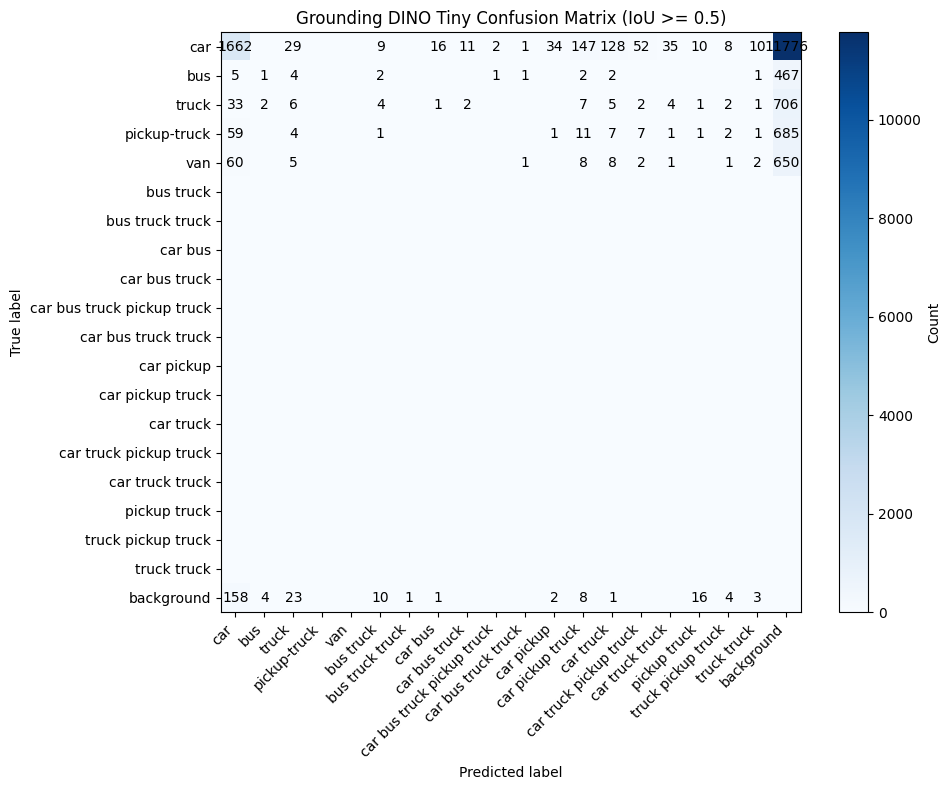

Confusion matches saved to /content/drive/MyDrive/Kdrone4/predictions/grounding_dino_tiny/test_confusion_matches.csv
Confusion matrix CSV saved to /content/drive/MyDrive/Kdrone4/predictions/grounding_dino_tiny/test_confusion_matrix.csv
Confusion matrix plot saved to /content/drive/MyDrive/Kdrone4/predictions/grounding_dino_tiny/test_confusion_matrix.png


Predicted label,car,bus,truck,pickup-truck,van,bus truck,bus truck truck,car bus,car bus truck,car bus truck pickup truck,car bus truck truck,car pickup,car pickup truck,car truck,car truck pickup truck,car truck truck,pickup truck,truck pickup truck,truck truck,background
True label,,,,,,,,,,,,,,,,,,,,
car,1662,0,29,0,0,9,0,16,11,2,1,34,147,128,52,35,10,8,10,11776
bus,5,1,4,0,0,2,0,0,0,1,1,0,2,2,0,0,0,0,1,467
truck,33,2,6,0,0,4,0,1,2,0,0,0,7,5,2,4,1,2,1,706
pickup-truck,59,0,4,0,0,1,0,0,0,0,0,1,11,7,7,1,1,2,1,685
van,60,0,5,0,0,0,0,0,0,0,1,0,8,8,2,1,0,1,2,650
bus truck,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
bus truck truck,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
car bus,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
car bus truck,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [18]:
if "test_images" not in globals():
    test_images = find_images(test_path)
    print(f"Rebuilt test image list: found {len(test_images)} test images")


detections_csv_path = output_dir / "test_detections.csv"
if not detections_csv_path.exists():
    raise FileNotFoundError(
        f"Could not find saved predictions at {detections_csv_path}. "
        "Run the Grounding DINO prediction section before plotting the confusion matrix."
    )

df_detections = pd.read_csv(detections_csv_path)
print(f"Loaded saved detections from {detections_csv_path}")


ground_truth_json_path = find_ground_truth_json()
if ground_truth_json_path is not None:
    print(f"Loading ground-truth annotations from {ground_truth_json_path}")
    coco_ground_truth_by_filename = build_coco_ground_truth_index(ground_truth_json_path)
else:
    print("No COCO JSON annotation file found. Falling back to YOLO .txt labels.")
    coco_ground_truth_by_filename = {}

confusion_rows = []

for image_path in tqdm(test_images, desc="Building confusion matrix"):
    image_path = Path(image_path)
    image_predictions = df_detections[df_detections["image_path"] == str(image_path)]

    if len(image_predictions):
        image_width = int(image_predictions.iloc[0]["image_width"])
        image_height = int(image_predictions.iloc[0]["image_height"])
    else:
        with Image.open(image_path) as image:
            image_width, image_height = image.size

    relative_image_path = str(image_path.relative_to(test_path))
    ground_truth_rows = coco_ground_truth_by_filename.get(
        relative_image_path,
        coco_ground_truth_by_filename.get(image_path.name)
    )

    if ground_truth_rows is None:
        ground_truth_rows = load_ground_truth_boxes(image_path, image_width, image_height)

    image_matches = match_predictions_to_ground_truth(ground_truth_rows, image_predictions)

    for match in image_matches:
        match["image_name"] = image_path.name
        match["image_path"] = str(image_path)
        confusion_rows.append(match)

df_confusion_matches = pd.DataFrame(confusion_rows)
confusion_matches_csv_path = output_dir / "test_confusion_matches.csv"
confusion_matrix_csv_path = output_dir / "test_confusion_matrix.csv"
confusion_matrix_png_path = output_dir / "test_confusion_matrix.png"

if df_confusion_matches.empty:
    raise ValueError(
        "No confusion-matrix rows were created. Check that the JSON annotation path is "
        "correct, usually test/_annotations.coco.json for COCO exports, and that image "
        "filenames in the JSON match the test images."
    )

df_confusion_matches.to_csv(confusion_matches_csv_path, index=False)

observed_labels = sorted(
    set(df_confusion_matches["true_label"])
    .union(set(df_confusion_matches["predicted_label"]))
    .difference({BACKGROUND_CLASS})
)
matrix_labels = [label for label in CLASS_NAMES if label in observed_labels]
matrix_labels += [label for label in observed_labels if label not in matrix_labels]
matrix_labels += [BACKGROUND_CLASS]

confusion_matrix_df = pd.crosstab(
    df_confusion_matches["true_label"],
    df_confusion_matches["predicted_label"],
    rownames=["True label"],
    colnames=["Predicted label"]
).reindex(index=matrix_labels, columns=matrix_labels, fill_value=0)

confusion_matrix_df.to_csv(confusion_matrix_csv_path)

plt.figure(figsize=(10, 8))
plt.imshow(confusion_matrix_df.values, cmap="Blues")
plt.title(f"Grounding DINO Tiny Confusion Matrix (IoU >= {IOU_THRESHOLD})")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(np.arange(len(matrix_labels)), matrix_labels, rotation=45, ha="right")
plt.yticks(np.arange(len(matrix_labels)), matrix_labels)
plt.colorbar(label="Count")

for row_index in range(len(matrix_labels)):
    for column_index in range(len(matrix_labels)):
        value = confusion_matrix_df.iloc[row_index, column_index]
        if value:
            plt.text(column_index, row_index, value, ha="center", va="center", color="black")

plt.tight_layout()
plt.savefig(confusion_matrix_png_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Confusion matches saved to {confusion_matches_csv_path}")
print(f"Confusion matrix CSV saved to {confusion_matrix_csv_path}")
print(f"Confusion matrix plot saved to {confusion_matrix_png_path}")
display(confusion_matrix_df)


#